<a href="https://colab.research.google.com/github/anapbatista/recinfo/blob/main/trabalho_pratico_recinfo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 1 - Recuperação de Informação (SCC0282)

**Integrantes do grupo:** Ana Paula de Abreu Batista - 12688424

**Dataset:** Cranfield (via biblioteca `ir_datasets`)

Este notebook implementa e avalia dois modelos clássicos de Recuperação de Informação — o **Modelo Vetorial (TF-IDF + Similaridade do Cosseno)** e o **Modelo Probabilístico BM25** — comparando quatro estratégias de pré-processamento, realizando avaliação quantitativa (Precision@10, Recall@10, MAP, F1@10, MRR e NDCG@10), análise qualitativa por consulta, variação de parâmetros do BM25 e análise de erros, conforme os requisitos do enunciado.


## Configuração do Dataset Cranfield
Instalando a biblioteca `ir-datasets` para acessar os dados de forma estruturada.

In [1]:
!pip install ir-datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.8/947.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.7 MB/s eta 0:00:00


Agora, vamos importar a biblioteca e carregar o dataset Cranfield, explorando a estrutura de documentos, queries e qrels (relevâncias).

In [2]:
import ir_datasets
import pandas as pd
import numpy as np

# Carrega o dataset Cranfield
dataset = ir_datasets.load("cranfield")

# Converte os documentos para um DataFrame do Pandas
docs_df = pd.DataFrame([{ 'doc_id': doc.doc_id, 'title': doc.title, 'text': doc.text, 'author': doc.author, 'bib': doc.bib } for doc in dataset.docs_iter()])

# Converte as queries (consultas) para um DataFrame
queries_df = pd.DataFrame([{ 'query_id': query.query_id, 'text': query.text } for query in dataset.queries_iter()])

# Converte os qrels (julgamentos de relevância) para um DataFrame
qrels_df = pd.DataFrame([{ 'query_id': qrel.query_id, 'doc_id': qrel.doc_id, 'relevance': qrel.relevance, 'iteration': qrel.iteration } for qrel in dataset.qrels_iter()])

# Garante que os ids sejam tratados como string em todo o notebook (evita bugs de comparação int/str)
docs_df['doc_id'] = docs_df['doc_id'].astype(str)
queries_df['query_id'] = queries_df['query_id'].astype(str)
qrels_df['query_id'] = qrels_df['query_id'].astype(str)
qrels_df['doc_id'] = qrels_df['doc_id'].astype(str)

# Exibe informações gerais e as primeiras linhas de cada conjunto
print(f"Total de Documentos: {len(docs_df)}")
print(f"Total de Queries: {len(queries_df)}")
print(f"Total de Julgamentos de Relevância (Qrels): {len(qrels_df)}")


[INFO] [starting] http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz
[INFO] [finished] http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz: [00:00] [507kB] [1.05MB/s]


Total de Documentos: 1400
Total de Queries: 225
Total de Julgamentos de Relevância (Qrels): 1837


In [3]:
print("--- Amostra de Documentos ---")
display(docs_df.head(2))

print("\n--- Amostra de Queries ---")
display(queries_df.head(2))

print("\n--- Amostra de Qrels ---")
display(qrels_df.head(2))

print("\n--- Distribuição dos graus de relevância nos Qrels ---")
display(qrels_df['relevance'].value_counts().sort_index())


--- Amostra de Documentos ---


,doc_id,title,text,author,bib
0,1,experimental investigation of the aerodynamics...,experimental investigation of the aerodynamics...,"brenckman,m.","j. ae. scs. 25, 1958, 324."
1,2,simple shear flow past a flat plate in an inco...,simple shear flow past a flat plate in an inco...,ting-yili,"department of aeronautical engineering, rensse..."



--- Amostra de Queries ---


,query_id,text
0,1,what similarity laws must be obeyed when const...
1,2,what are the structural and aeroelastic proble...



--- Amostra de Qrels ---


,query_id,doc_id,relevance,iteration
0,1,184,2,0
1,1,29,2,0



--- Distribuição dos graus de relevância nos Qrels ---


,count
relevance,
-1,225
1,128
2,387
3,734
4,363


## Etapa 1: Pré-processamento

Nesta etapa, preparamos o texto dos documentos e das queries. Vamos utilizar a biblioteca `nltk` para obter a lista de stopwords em inglês e o algoritmo de Stemming (Porter Stemmer). Em seguida, criaremos funções para processar os textos seguindo as quatro configurações mínimas exigidas pelo enunciado:
1. **Básico (Raw):** apenas normalização para minúsculas e tokenização (remoção de pontuação), sem remoção de stopwords e sem stemming.
2. **Stopwords:** remoção de palavras vazias (artigos, preposições, etc.), sem stemming.
3. **Stemming:** aplicação de redução ao radical (Porter Stemmer), sem remoção de stopwords.
4. **Stopwords + Stemming:** remoção de stopwords seguida de stemming.

Essas quatro configurações serão aplicadas tanto aos documentos quanto às consultas, e depois serão comparadas quantitativamente na Etapa 4 (não escolhemos a priori qual é "melhor" — isso é resultado do experimento).

In [4]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import PorterStemmer

# Faz o download dos recursos necessários do NLTK
nltk.download('stopwords')
nltk.download('punkt')

# Inicializa os componentes
tokenizer = RegexpTokenizer(r'\w+') # Tokeniza removendo pontuação
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text, remove_stopwords=False, use_stemming=False):
    # 1. Normalização para letras minúsculas
    text = str(text).lower()

    # 2. Tokenização
    tokens = tokenizer.tokenize(text)

    # 3. Tratamento de Stopwords
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]

    # 4. Stemming
    if use_stemming:
        tokens = [stemmer.stem(token) for token in tokens]

    return tokens


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Agora, vamos aplicar as 4 variações de pré-processamento aos nossos DataFrames de documentos e consultas. Para os documentos, concatenamos título e texto (`full_text`) como conteúdo indexável — decisão de projeto que aumenta a cobertura de vocabulário de cada documento.

In [5]:
# Criando as 4 representações para os Documentos (usando título + texto como conteúdo principal)
docs_df['full_text'] = docs_df['title'] + " " + docs_df['text']

docs_df['tokens_basico'] = docs_df['full_text'].apply(lambda x: preprocess(x, remove_stopwords=False, use_stemming=False))
docs_df['tokens_stopwords'] = docs_df['full_text'].apply(lambda x: preprocess(x, remove_stopwords=True, use_stemming=False))
docs_df['tokens_stemming'] = docs_df['full_text'].apply(lambda x: preprocess(x, remove_stopwords=False, use_stemming=True))
docs_df['tokens_both'] = docs_df['full_text'].apply(lambda x: preprocess(x, remove_stopwords=True, use_stemming=True))

# Criando as 4 representações para as Queries
queries_df['tokens_basico'] = queries_df['text'].apply(lambda x: preprocess(x, remove_stopwords=False, use_stemming=False))
queries_df['tokens_stopwords'] = queries_df['text'].apply(lambda x: preprocess(x, remove_stopwords=True, use_stemming=False))
queries_df['tokens_stemming'] = queries_df['text'].apply(lambda x: preprocess(x, remove_stopwords=False, use_stemming=True))
queries_df['tokens_both'] = queries_df['text'].apply(lambda x: preprocess(x, remove_stopwords=True, use_stemming=True))

# Dicionário central que referencia as 4 configurações de pré-processamento usadas no restante do notebook
configuracoes = {
    'basico': 'tokens_basico',
    'stopwords': 'tokens_stopwords',
    'stemming': 'tokens_stemming',
    'both': 'tokens_both'
}

print("Pré-processamento concluído com sucesso para documentos e consultas!")


Pré-processamento concluído com sucesso para documentos e consultas!


In [6]:
# Demonstração do resultado do pré-processamento em um exemplo
exemplo_doc = docs_df.iloc[0]
print(f"Texto Original do Doc 1: {exemplo_doc['full_text'][:200]}...")
print(f"\n1. Básico: {exemplo_doc['tokens_basico'][:10]}")
print(f"2. Sem Stopwords: {exemplo_doc['tokens_stopwords'][:10]}")
print(f"3. Com Stemming: {exemplo_doc['tokens_stemming'][:10]}")
print(f"4. Ambos: {exemplo_doc['tokens_both'][:10]}")

print(f"\nTamanho médio dos documentos (em tokens) por configuração:")
for nome, col in configuracoes.items():
    tam_medio = docs_df[col].apply(len).mean()
    print(f"  {nome:10s}: {tam_medio:.2f} tokens/documento em média")


Texto Original do Doc 1: experimental investigation of the aerodynamics of a
wing in a slipstream . experimental investigation of the aerodynamics of a
wing in a slipstream .
  an experimental study of a wing in a propeller s...

1. Básico: ['experimental', 'investigation', 'of', 'the', 'aerodynamics', 'of', 'a', 'wing', 'in', 'a']
2. Sem Stopwords: ['experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream', 'experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream']
3. Com Stemming: ['experiment', 'investig', 'of', 'the', 'aerodynam', 'of', 'a', 'wing', 'in', 'a']
4. Ambos: ['experiment', 'investig', 'aerodynam', 'wing', 'slipstream', 'experiment', 'investig', 'aerodynam', 'wing', 'slipstream']

Tamanho médio dos documentos (em tokens) por configuração:
  basico    : 173.72 tokens/documento em média
  stopwords : 102.94 tokens/documento em média
  stemming  : 173.72 tokens/documento em média
  both      : 102.94 tokens/documento em média


## Etapa 2: Modelo Vetorial (TF-IDF e Similaridade do Cosseno)

**Representação:** cada documento e cada consulta são representados como um vetor em um espaço vetorial de $|V|$ dimensões, onde $|V|$ é o tamanho do vocabulário (número de termos únicos após o pré-processamento). A coordenada $i$ do vetor de um documento $d$ é o peso TF-IDF do termo $i$ nesse documento:

$$w_{i,d} = tf_{i,d} \times idf_i, \qquad idf_i = \log\left(\frac{N}{df_i}\right) + 1$$

onde $tf_{i,d}$ é a frequência do termo $i$ no documento $d$, $N$ é o número total de documentos e $df_i$ é o número de documentos em que o termo $i$ ocorre (usamos a implementação padrão do `TfidfVectorizer` do scikit-learn, que normaliza cada vetor de documento pela norma L2). A consulta é projetada no **mesmo espaço vetorial** dos documentos (mesmo vocabulário, mesmo IDF aprendido no corpus), usando `vectorizer.transform()` em vez de `fit_transform()` — isso é essencial: se ajustássemos um vocabulário novo para a consulta, os vetores não seriam comparáveis.

**Cálculo do score:** o score de similaridade entre a consulta $q$ e um documento $d$ é o cosseno do ângulo entre os dois vetores:

$$\text{sim}(q,d) = \cos(\theta) = \frac{\vec{q}\cdot\vec{d}}{\lVert \vec{q}\rVert \lVert \vec{d}\rVert}$$

Quanto mais próximo de 1, mais similar (direção) é o vetor do documento ao vetor da consulta; termos ausentes em ambos não contribuem, e a normalização faz com que documentos longos não sejam artificialmente favorecidos apenas por conter mais palavras. O ranking final ordena os documentos por esse score em ordem decrescente.

Vamos construir um `TfidfVectorizer` e calcular a matriz TF-IDF **para cada uma das 4 configurações de pré-processamento**, permitindo comparar o efeito do pré-processamento também no Modelo Vetorial.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Função auxiliar: como os tokens já foram pré-processados manualmente (Etapa 1),
# usamos um tokenizer/preprocessor "identidade" para impedir que o TfidfVectorizer
# reprocesse o texto (ele receberia listas de tokens já prontas).
def identity_tokenizer(text_list):
    return text_list

# Dicionário para guardar os vetorizadores e as matrizes TF-IDF de cada configuração
modelos_vetoriais = {}

for nome_config, col_tokens in configuracoes.items():
    vectorizer = TfidfVectorizer(
        tokenizer=identity_tokenizer,
        lowercase=False,
        preprocessor=identity_tokenizer,
        token_pattern=None
    )

    # Ajusta o vocabulário e transforma os documentos em vetores TF-IDF
    tfidf_matrix = vectorizer.fit_transform(docs_df[col_tokens])

    modelos_vetoriais[nome_config] = {
        'vectorizer': vectorizer,
        'tfidf_matrix': tfidf_matrix
    }

    print(f"Configuração '{nome_config}': {tfidf_matrix.shape[1]} termos únicos no vocabulário.")


Configuração 'basico': 7471 termos únicos no vocabulário.
Configuração 'stopwords': 7352 termos únicos no vocabulário.
Configuração 'stemming': 4820 termos únicos no vocabulário.
Configuração 'both': 4709 termos únicos no vocabulário.


Com os modelos TF-IDF criados, vamos implementar a função de recuperação: dada uma consulta (já tokenizada) e uma configuração de pré-processamento, a função projeta a consulta no espaço vetorial daquela configuração (`vectorizer.transform`), calcula a similaridade do cosseno contra todos os documentos e retorna o ranking ordenado por score decrescente.

In [8]:
def buscar_modelo_vetorial(query_tokens, nome_config, top_n=None):
    # Recupera o vetorizador e a matriz de documentos adequados
    vectorizer = modelos_vetoriais[nome_config]['vectorizer']
    tfidf_matrix = modelos_vetoriais[nome_config]['tfidf_matrix']

    # Transforma a query usando o MESMO vetorizador (vocabulário e IDF) do corpus de documentos
    query_vector = vectorizer.transform([query_tokens])

    # Calcula a similaridade do cosseno entre o vetor da query e todos os documentos
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Cria uma lista de tuplas (doc_id, score), mantendo apenas documentos com alguma correspondência
    ranking = []
    for idx, score in enumerate(scores):
        if score > 0.0:
            doc_id = docs_df.iloc[idx]['doc_id']
            ranking.append((doc_id, float(score)))

    # Ordena o ranking pelo score de forma decrescente
    ranking = sorted(ranking, key=lambda x: x[1], reverse=True)

    if top_n:
        return ranking[:top_n]
    return ranking


In [9]:
# Demonstração: Buscando com a primeira query usando a configuração 'both' (Stopwords + Stemming)
exemplo_query = queries_df.iloc[0]
tokens_exemplo = exemplo_query['tokens_both']

print(f"Query Original: {exemplo_query['text']}")
print(f"Tokens da Query: {tokens_exemplo}")

resultados = buscar_modelo_vetorial(tokens_exemplo, 'both', top_n=5)
print("\n--- Top 5 Documentos Recuperados ---")
for ranking_pos, (doc_id, score) in enumerate(resultados, 1):
    titulo_doc = docs_df[docs_df['doc_id'] == doc_id]['title'].values[0]
    print(f"{ranking_pos}. Doc ID {doc_id} - Score: {score:.4f} | Título: {titulo_doc[:80]}...")


Query Original: what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed aircraft .
Tokens da Query: ['similar', 'law', 'must', 'obey', 'construct', 'aeroelast', 'model', 'heat', 'high', 'speed', 'aircraft']

--- Top 5 Documentos Recuperados ---
1. Doc ID 51 - Score: 0.3108 | Título: theory of aircraft structural models subjected to aerodynamic
heating and extern...
2. Doc ID 184 - Score: 0.2700 | Título: scale models for thermo-aeroelastic research ....
3. Doc ID 12 - Score: 0.2425 | Título: some structural and aerelastic considerations of high
speed flight ....
4. Doc ID 746 - Score: 0.2384 | Título: aeroelastic problems in connection with high speed
flight ....
5. Doc ID 359 - Score: 0.2203 | Título: note on the hypersonic similarity law for an unyawed
cone ....


## Etapa 3: Modelo Probabilístico (BM25)

Implementamos o BM25 **explicitamente** (sem usar uma biblioteca que esconda o cálculo do score), seguindo a formulação clássica de Robertson & Zaragoza. O score de um documento $d$ para uma consulta $q$ é:

$$\text{score}(q,d) = \sum_{t \in q} IDF(t) \cdot \frac{f_{t,d}\,(k_1+1)}{f_{t,d} + k_1\left(1 - b + b\cdot\frac{|d|}{avgdl}\right)}$$

onde:
- $f_{t,d}$ é a frequência do termo $t$ no documento $d$;
- $|d|$ é o comprimento (em tokens) do documento $d$ e $avgdl$ é o comprimento médio dos documentos do corpus;
- $k_1$ controla a **saturação da frequência de termos** — quanto maior $k_1$, mais repetições de um termo continuam aumentando o score (com $k_1 \to 0$ o modelo se torna quase binário: só importa se o termo aparece ou não);
- $b \in [0,1]$ controla a **normalização pelo comprimento do documento** — com $b=0$ não há penalização por tamanho; com $b=1$ a penalização é total;
- $IDF(t) = \log\left(\dfrac{N - df_t + 0.5}{df_t + 0.5} + 1\right)$ é o IDF probabilístico do BM25 (o "+1" evita valores negativos para termos muito frequentes, uma variante comum, tipo Lucene).

A classe abaixo pré-calcula, para cada configuração de pré-processamento, as frequências de termos por documento, os comprimentos dos documentos, o `avgdl` e o IDF de cada termo do vocabulário — e depois calcula o score sob demanda para qualquer par (consulta, documento), permitindo variar $k_1$ e $b$ livremente na Etapa 6.

In [10]:
import math
from collections import Counter

class BM25Modelo:
    def __init__(self, corpus_tokens, k1=1.5, b=0.75):
        self.k1 = k1
        self.b = b
        self.corpus_size = len(corpus_tokens)
        self.doc_lengths = [len(doc) for doc in corpus_tokens]
        self.avgdl = sum(self.doc_lengths) / self.corpus_size

        # Frequência de termos por documento e contagem de documentos que possuem cada termo
        self.doc_term_freqs = [Counter(doc) for doc in corpus_tokens]
        self.doc_freqs = {}

        for doc in corpus_tokens:
            for term in set(doc):
                self.doc_freqs[term] = self.doc_freqs.get(term, 0) + 1

        # Pré-calcula o IDF (fórmula probabilística do BM25 / Okapi, variante Lucene com +1)
        self.idf = {}
        for term, df in self.doc_freqs.items():
            self.idf[term] = math.log((self.corpus_size - df + 0.5) / (df + 0.5) + 1.0)

    def obter_score(self, query_tokens, doc_index):
        score = 0.0
        doc_len = self.doc_lengths[doc_index]
        term_freqs = self.doc_term_freqs[doc_index]

        for term in query_tokens:
            if term not in self.doc_freqs:
                continue  # termo fora do vocabulário do corpus: não contribui (IDF indefinido)

            tf = term_freqs[term]
            idf_val = self.idf[term]

            # Numerador: saturação de frequência do termo (limitada por k1)
            numerador = tf * (self.k1 + 1)
            # Denominador: saturação + normalização pelo comprimento do documento (controlada por b)
            denominador = tf + self.k1 * (1 - self.b + self.b * (doc_len / self.avgdl)) + 1e-9
            # 1e-9: constante infinitesimal apenas para evitar divisão por zero quando k1=0 e tf=0
            score += idf_val * (numerador / denominador)

        return score

    def buscar(self, query_tokens, docs_df, top_n=None):
        ranking = []
        for idx in range(self.corpus_size):
            score = self.obter_score(query_tokens, idx)
            if score > 0.0:
                doc_id = docs_df.iloc[idx]['doc_id']
                ranking.append((doc_id, score))

        ranking = sorted(ranking, key=lambda x: x[1], reverse=True)

        if top_n:
            return ranking[:top_n]
        return ranking


Agora, vamos instanciar o modelo BM25 (com os parâmetros padrão $k_1=1.5$, $b=0.75$, valores comumente recomendados na literatura) para cada uma das 4 configurações de pré-processamento que criamos. A variação sistemática de $k_1$ e $b$ é feita separadamente na Etapa 6.

In [11]:
modelos_bm25 = {}

# Criando instâncias do BM25 para cada uma das configurações de tokens
for nome_config, col_tokens in configuracoes.items():
    modelos_bm25[nome_config] = BM25Modelo(docs_df[col_tokens].tolist(), k1=1.5, b=0.75)
    print(f"Modelo BM25 inicializado para a configuração '{nome_config}'.")


Modelo BM25 inicializado para a configuração 'basico'.
Modelo BM25 inicializado para a configuração 'stopwords'.
Modelo BM25 inicializado para a configuração 'stemming'.
Modelo BM25 inicializado para a configuração 'both'.


In [12]:
# Demonstração: Buscando com a primeira query no BM25 usando a configuração 'both'
tokens_exemplo = queries_df.iloc[0]['tokens_both']

resultados_bm25 = modelos_bm25['both'].buscar(tokens_exemplo, docs_df, top_n=5)
print("\n--- Top 5 Documentos Recuperados pelo BM25 ---")
for ranking_pos, (doc_id, score) in enumerate(resultados_bm25, 1):
    titulo_doc = docs_df[docs_df['doc_id'] == doc_id]['title'].values[0]
    print(f"{ranking_pos}. Doc ID {doc_id} - Score BM25: {score:.4f} | Título: {titulo_doc[:80]}...")



--- Top 5 Documentos Recuperados pelo BM25 ---
1. Doc ID 51 - Score BM25: 23.4460 | Título: theory of aircraft structural models subjected to aerodynamic
heating and extern...
2. Doc ID 486 - Score BM25: 22.1423 | Título: similarity laws for aerothermoelastic testing ....
3. Doc ID 12 - Score BM25: 19.6756 | Título: some structural and aerelastic considerations of high
speed flight ....
4. Doc ID 184 - Score BM25: 19.0324 | Título: scale models for thermo-aeroelastic research ....
5. Doc ID 878 - Score BM25: 17.2506 | Título: experimental model techniques and equipment for flutter
investigations ....


## Etapa 4: Avaliação Quantitativa

Nesta etapa implementamos as métricas de avaliação e calculamos o desempenho dos dois modelos (Vetorial e BM25) para as quatro variações de pré-processamento, **por consulta e agregado** (média sobre todas as consultas), conforme exigido.

### Definição de relevância binária
Seguindo o enunciado: consideramos **relevante** todo documento com grau de relevância $\geq 1$ nos qrels. Julgamentos com valor `-1` e documentos não julgados (ausentes dos qrels) são tratados como **não relevantes**. Essa definição é usada em Precision@10, Recall@10, MAP, F1@10 e MRR (todas métricas binárias).

### Relevância graduada (para NDCG)
Para o NDCG@10 usamos os graus positivos dos qrels como relevância graduada. **Observação importante sobre a escala do Cranfield:** nesta coleção o grau `1` significa a *resposta mais relevante* e o grau `4` significa *relevância mínima* (ou seja, quanto **menor** o número, **maior** a relevância) — o oposto do que normalmente se assume em outras coleções (onde grau maior = mais relevante). Por isso, antes de calcular o NDCG, invertemos a escala para um "peso de ganho" $g$ consistente com a definição usual de DCG (ganho maior ⇒ documento mais relevante):

$$g(\text{grau}) = \begin{cases} 5 - \text{grau}, & \text{se grau} \in \{1,2,3,4\} \\ 0, & \text{caso contrário (não relevante ou não julgado)}\end{cases}$$

Assim, grau 1 (melhor resposta) recebe peso 4, e grau 4 (relevância mínima) recebe peso 1. Sem essa correção, o NDCG penalizaria erroneamente os documentos mais relevantes da coleção.

### Métricas calculadas
- **Precision@10**: fração de documentos relevantes entre os 10 primeiros retornados.
- **Recall@10**: fração dos documentos relevantes da consulta que aparecem entre os 10 primeiros.
- **F1@10**: média harmônica entre Precision@10 e Recall@10.
- **MAP (Mean Average Precision)**: média da Average Precision (AP) sobre todas as consultas; a AP de uma consulta é a média das precisões calculadas em cada posição do ranking completo em que um documento relevante foi recuperado.
- **MRR (Mean Reciprocal Rank)**: média do inverso da posição do primeiro documento relevante recuperado.
- **NDCG@10**: Normalized Discounted Cumulative Gain nos 10 primeiros, usando a relevância graduada (com a inversão de escala descrita acima).

In [13]:
def obter_relevantes_por_query(qrels_df):
    """Para cada query, retorna o conjunto de doc_ids relevantes (grau >= 1) e o dicionário
    de graus de relevância originais (>=1) usado depois para o NDCG."""
    relevantes = {}
    graus = {}
    for _, row in qrels_df.iterrows():
        q_id = str(row['query_id'])
        doc_id = str(row['doc_id'])
        rel = int(row['relevance'])
        if rel >= 1:
            relevantes.setdefault(q_id, set()).add(doc_id)
            graus.setdefault(q_id, {})[doc_id] = rel
    return relevantes, graus

relevantes_reais, graus_reais = obter_relevantes_por_query(qrels_df)


def peso_ganho(grau):
    """Converte o grau de relevância do Cranfield (1=melhor ... 4=pior) em peso de ganho
    para o DCG (quanto maior o peso, mais relevante). Ver explicação na célula acima."""
    if grau is None or grau < 1:
        return 0
    return 5 - grau


def dcg_at_k(ganhos, k):
    dcg = 0.0
    for i, g in enumerate(ganhos[:k]):
        dcg += g / math.log2(i + 2)  # i+2 pois a posição 1 (i=0) usa log2(2)=1
    return dcg


def ndcg_at_k(ranking, graus_query, k=10):
    if not graus_query:
        return 0.0
    ganhos_obtidos = [peso_ganho(graus_query.get(str(doc_id))) for doc_id, _ in ranking[:k]]
    dcg = dcg_at_k(ganhos_obtidos, k)

    ganhos_ideais = sorted([peso_ganho(g) for g in graus_query.values()], reverse=True)
    idcg = dcg_at_k(ganhos_ideais, k)

    return dcg / idcg if idcg > 0 else 0.0


def reciprocal_rank(ranking, rel_docs):
    for idx, (doc_id, _) in enumerate(ranking):
        if str(doc_id) in rel_docs:
            return 1.0 / (idx + 1)
    return 0.0


def calcular_metricas_completas(ranking, rel_docs, graus_query=None, k=10):
    """Calcula Precision@k, Recall@k, F1@k, Average Precision, Reciprocal Rank e NDCG@k
    para um único ranking (lista ordenada de (doc_id, score)) de uma consulta."""
    if not rel_docs:
        return dict(precision=0.0, recall=0.0, f1=0.0, ap=0.0, rr=0.0, ndcg=0.0)

    top_k = ranking[:k]
    recuperados_k = [str(doc_id) for doc_id, _ in top_k]

    # Precision@k e Recall@k
    relevantes_recuperados_k = [d for d in recuperados_k if d in rel_docs]
    precision_at_k = len(relevantes_recuperados_k) / k
    recall_at_k = len(relevantes_recuperados_k) / len(rel_docs)

    # F1@k
    if (precision_at_k + recall_at_k) > 0:
        f1_at_k = 2 * precision_at_k * recall_at_k / (precision_at_k + recall_at_k)
    else:
        f1_at_k = 0.0

    # Average Precision (considerando o ranking completo retornado, não só o top-k)
    ap_soma = 0.0
    relevantes_encontrados = 0
    for idx, (doc_id, _) in enumerate(ranking):
        if str(doc_id) in rel_docs:
            relevantes_encontrados += 1
            ap_soma += relevantes_encontrados / (idx + 1)
    average_precision = ap_soma / len(rel_docs)

    # Reciprocal Rank
    rr = reciprocal_rank(ranking, rel_docs)

    # NDCG@k (relevância graduada)
    ndcg = ndcg_at_k(ranking, graus_query, k) if graus_query else 0.0

    return dict(precision=precision_at_k, recall=recall_at_k, f1=f1_at_k,
                ap=average_precision, rr=rr, ndcg=ndcg)


Agora, vamos rodar **todas** as consultas em **todas** as combinações de modelo (Vetorial, BM25) × pré-processamento (4 configurações), guardando o resultado **por consulta** (`df_resultados_por_query`) e depois o **agregado** (média por configuração/modelo, `df_resultados_agregados`). Ambos são exportados em CSV para compor a entrega de resultados completos.

In [14]:
resultados_por_query = []

for nome_config, col_tokens in configuracoes.items():
    for _, q_row in queries_df.iterrows():
        q_id = str(q_row['query_id'])
        q_tokens = q_row[col_tokens]

        # Ignora consultas sem nenhum julgamento de relevância positivo (não avaliáveis)
        if q_id not in relevantes_reais:
            continue

        rel_docs = relevantes_reais[q_id]
        graus_query = graus_reais.get(q_id, {})

        # --- Modelo Vetorial ---
        ranking_vet = buscar_modelo_vetorial(q_tokens, nome_config)
        m_vet = calcular_metricas_completas(ranking_vet, rel_docs, graus_query, k=10)
        resultados_por_query.append({
            'preprocessamento': nome_config, 'modelo': 'Vetorial (TF-IDF)', 'query_id': q_id,
            'precision_at_10': m_vet['precision'], 'recall_at_10': m_vet['recall'],
            'f1_at_10': m_vet['f1'], 'ap': m_vet['ap'], 'rr': m_vet['rr'], 'ndcg_at_10': m_vet['ndcg']
        })

        # --- BM25 ---
        ranking_bm = modelos_bm25[nome_config].buscar(q_tokens, docs_df)
        m_bm = calcular_metricas_completas(ranking_bm, rel_docs, graus_query, k=10)
        resultados_por_query.append({
            'preprocessamento': nome_config, 'modelo': 'BM25', 'query_id': q_id,
            'precision_at_10': m_bm['precision'], 'recall_at_10': m_bm['recall'],
            'f1_at_10': m_bm['f1'], 'ap': m_bm['ap'], 'rr': m_bm['rr'], 'ndcg_at_10': m_bm['ndcg']
        })

df_resultados_por_query = pd.DataFrame(resultados_por_query)

# Agregação (média por configuração de pré-processamento e modelo) -> métrica MAP, MRR médio, etc.
df_resultados_agregados = (
    df_resultados_por_query
    .groupby(['preprocessamento', 'modelo'])
    .agg(P_at_10=('precision_at_10', 'mean'),
         R_at_10=('recall_at_10', 'mean'),
         F1_at_10=('f1_at_10', 'mean'),
         MAP=('ap', 'mean'),
         MRR=('rr', 'mean'),
         NDCG_at_10=('ndcg_at_10', 'mean'))
    .reset_index()
    .sort_values(by='MAP', ascending=False)
)

# Exporta os resultados completos (por consulta e agregados) para a entrega do projeto
df_resultados_por_query.to_csv('resultados_por_consulta.csv', index=False)
df_resultados_agregados.to_csv('resultados_agregados.csv', index=False)

print(f"Total de linhas em resultados por consulta: {len(df_resultados_por_query)} "
      f"({len(configuracoes)} configs x 2 modelos x {df_resultados_por_query['query_id'].nunique()} queries avaliáveis)")
display(df_resultados_agregados)


Total de linhas em resultados por consulta: 1800 (4 configs x 2 modelos x 225 queries avaliáveis)


,preprocessamento,modelo,P_at_10,R_at_10,F1_at_10,MAP,MRR,NDCG_at_10
2,both,BM25,0.243111,0.407087,0.274711,0.319110,0.550923,0.380157
3,both,Vetorial (TF-IDF),0.243111,0.402349,0.273089,0.307499,0.533780,0.367446
4,stemming,BM25,0.236889,0.396606,0.267738,0.306694,0.535285,0.370654
5,stemming,Vetorial (TF-IDF),0.233778,0.385174,0.261670,0.298175,0.516227,0.354824
6,stopwords,BM25,0.237333,0.401324,0.269976,0.295755,0.529417,0.365582
7,stopwords,Vetorial (TF-IDF),0.223556,0.370429,0.251696,0.283820,0.516178,0.341043
0,basico,BM25,0.229778,0.387564,0.260967,0.282065,0.506332,0.349393
1,basico,Vetorial (TF-IDF),0.227111,0.371130,0.254371,0.277807,0.505288,0.341139


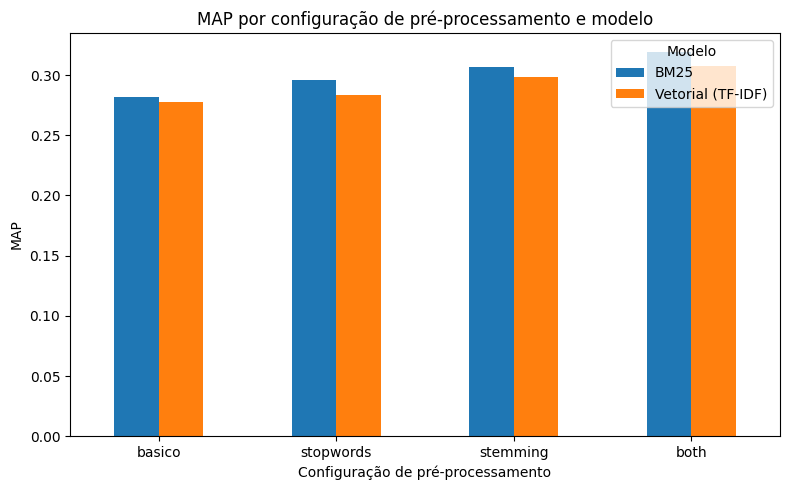

In [15]:
import matplotlib.pyplot as plt

# Gráfico 1: MAP por configuração de pré-processamento, para cada modelo
pivot_map = df_resultados_agregados.pivot(index='preprocessamento', columns='modelo', values='MAP')
pivot_map = pivot_map.reindex(['basico', 'stopwords', 'stemming', 'both'])

ax = pivot_map.plot(kind='bar', figsize=(8, 5), rot=0)
ax.set_title('MAP por configuração de pré-processamento e modelo')
ax.set_xlabel('Configuração de pré-processamento')
ax.set_ylabel('MAP')
ax.legend(title='Modelo')
plt.tight_layout()
plt.savefig('grafico_map_por_config.png', dpi=150)
plt.show()


Melhor configuração de pré-processamento (maior MAP): 'both'


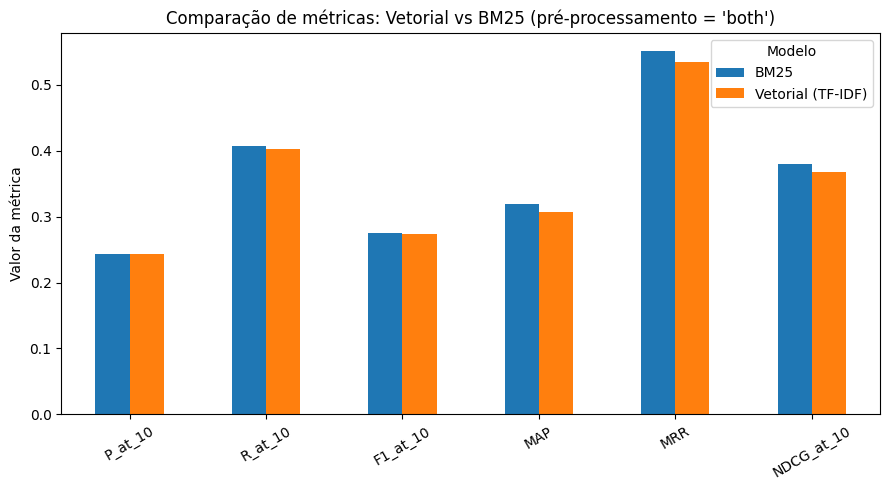

,preprocessamento,modelo,P_at_10,R_at_10,F1_at_10,MAP,MRR,NDCG_at_10
2,both,BM25,0.243111,0.407087,0.274711,0.319110,0.550923,0.380157
3,both,Vetorial (TF-IDF),0.243111,0.402349,0.273089,0.307499,0.533780,0.367446


In [16]:
# Gráfico 2: comparação de todas as métricas para a MELHOR configuração de pré-processamento
melhor_config = df_resultados_agregados.loc[df_resultados_agregados['MAP'].idxmax(), 'preprocessamento']
print(f"Melhor configuração de pré-processamento (maior MAP): '{melhor_config}'")

df_melhor = df_resultados_agregados[df_resultados_agregados['preprocessamento'] == melhor_config]
metricas_cols = ['P_at_10', 'R_at_10', 'F1_at_10', 'MAP', 'MRR', 'NDCG_at_10']

df_plot = df_melhor.set_index('modelo')[metricas_cols]
ax = df_plot.T.plot(kind='bar', figsize=(9, 5), rot=30)
ax.set_title(f"Comparação de métricas: Vetorial vs BM25 (pré-processamento = '{melhor_config}')")
ax.set_ylabel('Valor da métrica')
ax.legend(title='Modelo')
plt.tight_layout()
plt.savefig('grafico_comparacao_metricas.png', dpi=150)
plt.show()

display(df_melhor)


## Etapa 5: Comparação Detalhada e Análise por Consulta

Nesta seção comparamos, consulta a consulta, o desempenho (AP, e demais métricas) do **Modelo Vetorial** e do **BM25**, ambos usando a melhor configuração de pré-processamento identificada na Etapa 4 (`tokens_both`). Vamos identificar:
1. Duas (ou mais) consultas em que o **BM25** foi claramente superior;
2. Duas (ou mais) consultas em que o **Modelo Vetorial** foi claramente superior;
3. Duas consultas em que **ambos os modelos** tiveram desempenho insatisfatório.

Para cada caso, exibimos os **5 primeiros documentos retornados** por cada modelo, indicando quais são de fato relevantes segundo os qrels.

In [17]:
nome_config_analise = 'both'
col_tokens_analise = 'tokens_both'

analise_queries = []
for _, q_row in queries_df.iterrows():
    q_id = str(q_row['query_id'])
    q_tokens = q_row[col_tokens_analise]

    if q_id not in relevantes_reais:
        continue

    rel_docs = relevantes_reais[q_id]
    graus_query = graus_reais.get(q_id, {})

    ranking_vet = buscar_modelo_vetorial(q_tokens, nome_config_analise)
    m_vet = calcular_metricas_completas(ranking_vet, rel_docs, graus_query, k=10)

    ranking_bm = modelos_bm25[nome_config_analise].buscar(q_tokens, docs_df)
    m_bm = calcular_metricas_completas(ranking_bm, rel_docs, graus_query, k=10)

    analise_queries.append({
        'query_id': q_id,
        'texto_original': q_row['text'].strip(),
        'AP_Vetorial': m_vet['ap'], 'P10_Vetorial': m_vet['precision'], 'NDCG_Vetorial': m_vet['ndcg'],
        'AP_BM25': m_bm['ap'], 'P10_BM25': m_bm['precision'], 'NDCG_BM25': m_bm['ndcg'],
        'Diferenca_BM25_menos_Vetorial': m_bm['ap'] - m_vet['ap'],
        'Media_AP': (m_bm['ap'] + m_vet['ap']) / 2.0
    })

df_analise_queries = pd.DataFrame(analise_queries)
df_analise_queries.to_csv('analise_por_consulta_ambos_modelos.csv', index=False)
display(df_analise_queries.sort_values(by='Diferenca_BM25_menos_Vetorial', ascending=False).head(5))


,query_id,texto_original,AP_Vetorial,P10_Vetorial,NDCG_Vetorial,AP_BM25,P10_BM25,NDCG_BM25,Diferenca_BM25_menos_Vetorial,Media_AP
35,36,has anyone investigated relaxation effects on ...,0.064476,0.1,0.148041,0.502375,0.1,0.469279,0.437899,0.283426
172,173,references on lyapunov's method on the stabili...,0.583333,0.2,0.693426,1.000000,0.2,1.000000,0.416667,0.791667
14,15,material properties of photoelastic materials .,0.666667,0.2,0.650878,1.000000,0.2,0.859719,0.333333,0.833333
204,205,has anyone investigated theoretically whether ...,0.500000,0.2,0.650921,0.833333,0.2,0.919721,0.333333,0.666667
166,167,exact solution methods for calculating the abl...,0.088346,0.0,0.000000,0.416667,0.2,0.554066,0.328321,0.252506


In [18]:
def mostrar_top5_com_relevancia(ranking, rel_docs, docs_df, rotulo_modelo):
    """Exibe os 5 primeiros documentos de um ranking, indicando com [RELEVANTE] ou
    [não relevante] se cada um consta nos qrels da consulta (grau >= 1)."""
    print(f"  -- Top 5 ({rotulo_modelo}) --")
    if not ranking:
        print("     (nenhum documento recuperado)")
        return
    for pos, (doc_id, score) in enumerate(ranking[:5], 1):
        doc_id = str(doc_id)
        marcador = "[RELEVANTE]" if doc_id in rel_docs else "[não relevante]"
        titulo = docs_df[docs_df['doc_id'] == doc_id]['title'].values
        titulo = titulo[0].strip().replace(chr(10), ' ')[:70] if len(titulo) else "(título não encontrado)"
        print(f"     {pos}. Doc {doc_id:>5s} | score={score:.4f} | {marcador:16s} | {titulo}")


def analisar_e_exibir_query(q_id, motivo=""):
    q_row = queries_df[queries_df['query_id'] == q_id].iloc[0]
    q_tokens = q_row[col_tokens_analise]
    rel_docs = relevantes_reais[q_id]

    print("=" * 100)
    print(f"Query {q_id} {('- ' + motivo) if motivo else ''}")
    print(f"Texto: {q_row['text'].strip()}")
    print(f"Documentos relevantes (qrels): {sorted(rel_docs, key=int)}")

    ranking_vet = buscar_modelo_vetorial(q_tokens, nome_config_analise)
    ranking_bm = modelos_bm25[nome_config_analise].buscar(q_tokens, docs_df)

    mostrar_top5_com_relevancia(ranking_vet, rel_docs, docs_df, "Modelo Vetorial")
    mostrar_top5_com_relevancia(ranking_bm, rel_docs, docs_df, "BM25")
    print()


### 1. Consultas em que o BM25 foi claramente superior ao Modelo Vetorial

In [19]:
top_bm25_superior = df_analise_queries.sort_values(by='Diferenca_BM25_menos_Vetorial', ascending=False).head(2)
display(top_bm25_superior)

for _, row in top_bm25_superior.iterrows():
    analisar_e_exibir_query(row['query_id'], motivo=f"BM25 superior (ΔAP=+{row['Diferenca_BM25_menos_Vetorial']:.4f})")


,query_id,texto_original,AP_Vetorial,P10_Vetorial,NDCG_Vetorial,AP_BM25,P10_BM25,NDCG_BM25,Diferenca_BM25_menos_Vetorial,Media_AP
35,36,has anyone investigated relaxation effects on ...,0.064476,0.1,0.148041,0.502375,0.1,0.469279,0.437899,0.283426
172,173,references on lyapunov's method on the stabili...,0.583333,0.2,0.693426,1.000000,0.2,1.000000,0.416667,0.791667


Query 36 - BM25 superior (ΔAP=+0.4379)
Texto: has anyone investigated relaxation effects on gaseous heat transfer to a
suddenly heated wall .
Documentos relevantes (qrels): ['168', '169']
  -- Top 5 (Modelo Vetorial) --
     1. Doc   398 | score=0.2651 | [não relevante]  | heat transfer in turbulent shear flow .
     2. Doc   303 | score=0.2403 | [não relevante]  | effect of variable heat recombination on stagnation point heat transfe
     3. Doc   564 | score=0.2345 | [não relevante]  | local heat transfer and recovery temperature on a yawed cylinder at a 
     4. Doc   554 | score=0.2335 | [não relevante]  | generalized heat transfer formulas and graphs .
     5. Doc   623 | score=0.2307 | [não relevante]  | on the coupling between heat and mass transfer .
  -- Top 5 (BM25) --
     1. Doc   168 | score=18.2880 | [RELEVANTE]      | heat conduction through a gas with one inert internal model .
     2. Doc   623 | score=15.6841 | [não relevante]  | on the coupling between heat and mass 

### 2. Consultas em que o Modelo Vetorial foi claramente superior ao BM25

In [20]:
top_vetorial_superior = df_analise_queries.sort_values(by='Diferenca_BM25_menos_Vetorial', ascending=True).head(2)
display(top_vetorial_superior)

for _, row in top_vetorial_superior.iterrows():
    analisar_e_exibir_query(row['query_id'], motivo=f"Vetorial superior (ΔAP={row['Diferenca_BM25_menos_Vetorial']:.4f})")


,query_id,texto_original,AP_Vetorial,P10_Vetorial,NDCG_Vetorial,AP_BM25,P10_BM25,NDCG_BM25,Diferenca_BM25_menos_Vetorial,Media_AP
16,17,can the three-dimensional problem of a transve...,0.507937,0.1,0.703918,0.106944,0.1,0.272313,-0.400992,0.30744
94,95,what is the theoretical heat transfer distribu...,0.750000,0.2,0.587939,0.450000,0.2,0.470390,-0.300000,0.60000


Query 17 - Vetorial superior (ΔAP=-0.4010)
Texto: can the three-dimensional problem of a transverse potential flow about
a body of revolution be reduced to a two-dimensional problem .
Documentos relevantes (qrels): ['106', '196']
  -- Top 5 (Modelo Vetorial) --
     1. Doc   106 | score=0.4233 | [RELEVANTE]      | the transverse potential flow past a body of revolution .
     2. Doc  1281 | score=0.4218 | [não relevante]  | turbulent heat transfer on blunt-nosed bodies in two-dimensional and g
     3. Doc   700 | score=0.3878 | [não relevante]  | two and three-dimensional unsteady lift problems in high speed flight 
     4. Doc  1301 | score=0.3500 | [não relevante]  | compressible boundary layers on bodies of revolution .
     5. Doc   498 | score=0.3083 | [não relevante]  | calculation of potential flow about bodies of revolution having axes p
  -- Top 5 (BM25) --
     1. Doc  1108 | score=23.7305 | [não relevante]  | a study of second-order supersonic flow theory .
     2. Doc  1281

### 3. Consultas em que ambos os modelos apresentaram desempenho insatisfatório

Selecionamos as consultas com a **menor AP média** entre os dois modelos, exigindo que haja pelo menos um documento relevante conhecido (`rel_docs` não vazio) para que a baixa pontuação não seja apenas artefato de uma consulta trivial/sem julgamentos suficientes.

In [21]:
piores_ambos = (
    df_analise_queries[df_analise_queries['Media_AP'] < 0.15]
    .sort_values(by='Media_AP', ascending=True)
    .head(2)
)

# Caso menos de 2 consultas atendam ao corte de 0.15, relaxamos o filtro
if len(piores_ambos) < 2:
    piores_ambos = df_analise_queries.sort_values(by='Media_AP', ascending=True).head(2)

display(piores_ambos)

for _, row in piores_ambos.iterrows():
    analisar_e_exibir_query(row['query_id'], motivo=f"Ambos insatisfatórios (AP Vet={row['AP_Vetorial']:.4f}, AP BM25={row['AP_BM25']:.4f})")


,query_id,texto_original,AP_Vetorial,P10_Vetorial,NDCG_Vetorial,AP_BM25,P10_BM25,NDCG_BM25,Diferenca_BM25_menos_Vetorial,Media_AP
12,13,what is the basic mechanism of the transonic a...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21,22,did anyone else discover that the turbulent sk...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Query 13 - Ambos insatisfatórios (AP Vet=0.0000, AP BM25=0.0000)
Texto: what is the basic mechanism of the transonic aileron buzz .
Documentos relevantes (qrels): ['64', '65', '265', '311']
  -- Top 5 (Modelo Vetorial) --
     1. Doc   496 | score=0.6158 | [não relevante]  | a theory of transonic aileron buzz, neglecting viscous effects .
     2. Doc   643 | score=0.2643 | [não relevante]  | an investigation of wing-aileron flutter using ground launched rocket 
     3. Doc   199 | score=0.2270 | [não relevante]  | measurement of two dimensional derivatives on a wing-aileron-tab syste
     4. Doc   313 | score=0.2258 | [não relevante]  | on alternative forms for the basic equations of transonic flow theory 
     5. Doc   903 | score=0.2247 | [não relevante]  | two dimensional transonic unsteady flow with shock waves .
  -- Top 5 (BM25) --
     1. Doc   496 | score=27.7334 | [não relevante]  | a theory of transonic aileron buzz, neglecting viscous effects .
     2. Doc   903 | score=15.6

### Hipóteses e Discussão Teórica

Com base nos dados extraídos acima, levantamos as seguintes hipóteses (a serem aprofundadas no relatório com os exemplos concretos exibidos anteriormente):

1. **Saturação de Frequência de Termos (TF-IDF vs BM25):** no Modelo Vetorial, o peso TF-IDF cresce sem limite superior restrito; se um documento repete exaustivamente um termo da consulta, seu score pode inflar desproporcionalmente. O BM25 introduz uma assíntota de saturação via $k_1$: a partir de poucas repetições, ocorrências adicionais do mesmo termo adicionam pouco score extra, reduzindo o impacto de documentos que "abusam" de um termo popular.

2. **Normalização do comprimento do documento:** documentos muito longos têm mais chance de coincidir termos com a consulta por acaso. O parâmetro $b$ do BM25 penaliza de forma ajustável documentos muito maiores que a média do corpus (`avgdl`); a normalização L2 do TF-IDF é mais rígida e pode, em alguns casos, penalizar documentos curtos e densos ou tolerar demais documentos longos e esparsos.

3. **Consultas em que o Modelo Vetorial se sobressai:** tende a ocorrer quando os termos-chave se repetem também **dentro da própria consulta** (reforçando seu peso no vetor de consulta) ou quando poucos termos raros e de alto IDF já definem exatamente o documento correto, sem a interferência da normalização de tamanho do BM25.

4. **Consultas "insatisfatórias" para ambos os modelos:** costumam ocorrer quando há forte descompasso vocabular entre consulta e documento relevante (o autor usa sinônimos/paráfrases em vez dos termos exatos da consulta) — problema que nenhum dos dois modelos de correspondência lexical (bag-of-words) consegue resolver, pois ambos dependem de casamento exato de termos (após stemming). Isso motiva, na Etapa 8, uma investigação mais profunda desses casos de erro.

## Etapa 6: Variação de Parâmetros do BM25 ($k_1$ e $b$)

Avaliamos todas as combinações da grade sugerida pelo enunciado, utilizando a melhor configuração de pré-processamento (`tokens_both`):
- $k_1 \in \{0.5,\ 1.2,\ 2.0\}$
- $b \in \{0.0,\ 0.75,\ 1.0\}$

Comparamos as 9 combinações usando **MAP** e **NDCG@10** (métrica adicional, conforme exigido: "MAP e pelo menos uma outra métrica"), discutimos o efeito de cada parâmetro e, em seguida, selecionamos uma consulta em que a alteração de $b$ provoca uma mudança perceptível no ranking.

In [22]:
resultados_parametros = []
k1_valores = [0.5, 1.2, 2.0]
b_valores = [0.0, 0.75, 1.0]
col_tokens_param = 'tokens_both'

for k1_val in k1_valores:
    for b_val in b_valores:
        modelo_teste = BM25Modelo(docs_df[col_tokens_param].tolist(), k1=k1_val, b=b_val)

        ap_lista, p10_lista, ndcg_lista = [], [], []

        for _, q_row in queries_df.iterrows():
            q_id = str(q_row['query_id'])
            q_tokens = q_row[col_tokens_param]

            if q_id not in relevantes_reais:
                continue

            rel_docs = relevantes_reais[q_id]
            graus_query = graus_reais.get(q_id, {})
            ranking = modelo_teste.buscar(q_tokens, docs_df)

            m = calcular_metricas_completas(ranking, rel_docs, graus_query, k=10)
            ap_lista.append(m['ap'])
            p10_lista.append(m['precision'])
            ndcg_lista.append(m['ndcg'])

        resultados_parametros.append({
            'k1': k1_val, 'b': b_val,
            'MAP': np.mean(ap_lista), 'P@10': np.mean(p10_lista), 'NDCG@10': np.mean(ndcg_lista)
        })

df_parametros = pd.DataFrame(resultados_parametros)
df_parametros.to_csv('resultados_variacao_parametros_bm25.csv', index=False)
display(df_parametros.sort_values(by='MAP', ascending=False))


,k1,b,MAP,P@10,NDCG@10
7,2.0,0.75,0.320074,0.248000,0.384696
8,2.0,1.00,0.318557,0.242667,0.375770
4,1.2,0.75,0.315020,0.240000,0.374248
5,1.2,1.00,0.310845,0.239111,0.370074
2,0.5,1.00,0.299866,0.224889,0.358233
6,2.0,0.00,0.298976,0.223111,0.358764
1,0.5,0.75,0.297643,0.223111,0.356574
3,1.2,0.00,0.290649,0.216889,0.346298
0,0.5,0.00,0.278125,0.208444,0.332686


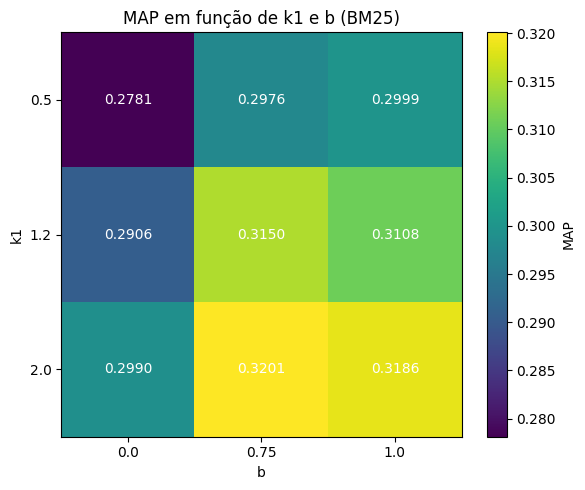

In [23]:
# Heatmap de MAP em função de k1 e b, para visualizar o efeito conjunto dos dois parâmetros
pivot_param = df_parametros.pivot(index='k1', columns='b', values='MAP')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pivot_param.values, cmap='viridis', aspect='auto')

ax.set_xticks(range(len(pivot_param.columns)))
ax.set_xticklabels(pivot_param.columns)
ax.set_yticks(range(len(pivot_param.index)))
ax.set_yticklabels(pivot_param.index)
ax.set_xlabel('b')
ax.set_ylabel('k1')
ax.set_title('MAP em função de k1 e b (BM25)')

for i in range(pivot_param.shape[0]):
    for j in range(pivot_param.shape[1]):
        ax.text(j, i, f"{pivot_param.values[i, j]:.4f}", ha='center', va='center', color='white')

fig.colorbar(im, ax=ax, label='MAP')
plt.tight_layout()
plt.savefig('grafico_heatmap_k1_b.png', dpi=150)
plt.show()


### Encontrando uma consulta sensível à variação de $b$

Agora buscamos programaticamente, entre todas as consultas, aquela em que alterar exclusivamente $b$ de `0.0` (sem normalização de tamanho) para `1.0` (normalização total), mantendo $k_1=1.5$ fixo, causa a maior mudança no Top 5 do ranking (maior diferença simétrica de conjuntos).

In [24]:
bm25_b0 = BM25Modelo(docs_df['tokens_both'].tolist(), k1=1.5, b=0.0)
bm25_b1 = BM25Modelo(docs_df['tokens_both'].tolist(), k1=1.5, b=1.0)

maior_diferenca = -1
query_alvo_id = None
ranking_b0_alvo, ranking_b1_alvo = [], []

for _, q_row in queries_df.iterrows():
    q_id = str(q_row['query_id'])
    q_tokens = q_row['tokens_both']

    if q_id not in relevantes_reais:
        continue

    r_b0 = [str(doc_id) for doc_id, _ in bm25_b0.buscar(q_tokens, docs_df, top_n=5)]
    r_b1 = [str(doc_id) for doc_id, _ in bm25_b1.buscar(q_tokens, docs_df, top_n=5)]

    if len(r_b0) < 5 or len(r_b1) < 5:
        continue

    diferenca = len(set(r_b0).symmetric_difference(set(r_b1)))
    if diferenca > maior_diferenca:
        maior_diferenca = diferenca
        query_alvo_id = q_id
        ranking_b0_alvo, ranking_b1_alvo = r_b0, r_b1

info_query = queries_df[queries_df['query_id'] == query_alvo_id].iloc[0]
rel_docs_alvo = relevantes_reais.get(query_alvo_id, set())

print(f"Consulta selecionada: Query ID {query_alvo_id} (diferença simétrica no Top 5 = {maior_diferenca}/5)")
print(f"Texto: {info_query['text'].strip()}")
print(f"Documentos relevantes (qrels): {sorted(rel_docs_alvo, key=int) if rel_docs_alvo else '(nenhum julgamento positivo)'}")
print(f"\nTop 5 com b=0.0 (sem normalização de tamanho): "
      f"{[(d, 'REL' if d in rel_docs_alvo else '-') for d in ranking_b0_alvo]}")
print(f"Top 5 com b=1.0 (normalização total de tamanho):  "
      f"{[(d, 'REL' if d in rel_docs_alvo else '-') for d in ranking_b1_alvo]}")


Consulta selecionada: Query ID 67 (diferença simétrica no Top 5 = 10/5)
Texto: can series expansions be found for the boundary layer on a flat plate in
a shear flow .
Documentos relevantes (qrels): ['2', '3', '4', '128', '180', '323', '324', '389', '393', '394', '629', '659', '664', '1302']

Top 5 com b=0.0 (sem normalização de tamanho): [('9', '-'), ('2', 'REL'), ('1107', '-'), ('72', '-'), ('306', '-')]
Top 5 com b=1.0 (normalização total de tamanho):  [('3', 'REL'), ('393', 'REL'), ('180', 'REL'), ('4', 'REL'), ('664', 'REL')]


### Discussão do efeito dos parâmetros

- **$k_1$ (saturação de termos):** valores maiores de $k_1$ permitem que repetições adicionais de um termo continuem contribuindo para o score de forma mais gradual (menos saturação); valores menores tornam o BM25 quase binário em relação à presença do termo. O efeito líquido sobre o MAP depende de quão informativa é a repetição de termos no corpus Cranfield — observe no heatmap acima se o MAP cresce, decresce ou se estabiliza ao longo das colunas para cada valor de $k_1$, e relacione isso ao tamanho médio e à redundância lexical dos documentos (calculados na Etapa 1).
- **$b$ (normalização de comprimento):** $b=0$ não penaliza documentos longos, favorecendo-os quando eles acumulam mais correspondências de termo apenas por serem extensos; $b=1$ aplica a penalização máxima, favorecendo documentos curtos e densos. O valor intermediário $b=0.75$ costuma ser um equilíbrio robusto na literatura — compare com os resultados observados no heatmap para este corpus específico.
- **Consulta sensível a $b$:** o exemplo acima ilustra concretamente esse efeito — compare os documentos favorecidos em cada extremo e relacione ao comprimento desses documentos (`doc_lengths` da classe `BM25Modelo`) frente ao `avgdl` do corpus.

*(Preencher o relatório com os valores numéricos exatos obtidos na execução, citando a linha do `df_parametros` correspondente à melhor e à pior combinação, e o `query_alvo_id` encontrado.)*

## Etapa 7: Modificação de Consultas e Análise de Impacto

Selecionamos 5 consultas da coleção Cranfield e criamos manualmente uma versão alternativa de cada uma (expansão com sinônimos/termos técnicos, maior especificidade, simplificação, generalização e remoção de ruído/termos de contexto), conforme sugerido no enunciado. As versões original e modificada são executadas no Modelo Vetorial e no BM25 (configuração `both`, BM25 com $k_1=2.0,\ b=0.75$ — melhor combinação encontrada na Etapa 6), comparando tanto a **sobreposição do Top-10** quanto a **variação da métrica AP** em relação aos qrels (já que as consultas modificadas ainda se referem ao mesmo `query_id`/necessidade de informação original, é possível reavaliar seu desempenho quantitativo).

### Estratégia de modificação das consultas
1. **Query 1:** foco em "similarity laws for aeroelastic models" → expansão com sinônimos/termos técnicos.
2. **Query 3:** foco em "composite slabs" → consulta tornada mais específica.
3. **Query 15:** foco em "photoelastic materials" → simplificação/remoção de redundâncias.
4. **Query 95:** foco em "heat transfer around a hemisphere" → generalização (termo geométrico específico trocado por classe mais ampla).
5. **Query 173:** foco em "lyapunov's method" → remoção de termos de contexto, focando nos termos raros mais discriminantes.

In [25]:
queries_custom = [
    {
        'query_id': '1',
        'descricao': 'Expansão por sinônimos/termos técnicos',
        'original': 'what similarity laws must be obeyed when constructing aeroelastic models of heated high speed aircraft .',
        'modificada': 'what dynamic scale similarity laws govern wind tunnel testing of thermo-aeroelastic heated high speed structures .'
    },
    {
        'query_id': '3',
        'descricao': 'Tornando a consulta mais específica',
        'original': 'what problems of heat conduction in composite slabs have been solved .',
        'modificada': 'analytical transient temperature distribution and heat conduction problems in multilayer composite slabs .'
    },
    {
        'query_id': '15',
        'descricao': 'Simplificação / redução de redundâncias',
        'original': 'material properties of photoelastic materials .',
        'modificada': 'mechanical and optical properties of photoelastic specimens .'
    },
    {
        'query_id': '95',
        'descricao': 'Generalização (termo específico -> classe mais ampla)',
        'original': 'what is the theoretical heat transfer distribution around a hemisphere .',
        'modificada': 'theoretical heat transfer distribution around aerodynamic blunt bodies in hypersonic flow .'
    },
    {
        'query_id': '173',
        'descricao': 'Remoção de termos de contexto (foco em termos raros)',
        'original': "references on lyapunov's method on the stability of linear differential equations with periodic coefficients .",
        'modificada': 'lyapunov stability linear differential equations periodic .'
    }
]

bm25_otimo = BM25Modelo(docs_df['tokens_both'].tolist(), k1=2.0, b=0.75)

def obter_top_10(ranking):
    return [str(doc_id) for doc_id, _ in ranking[:10]]

resultados_modificacao = []

for q_info in queries_custom:
    q_id = q_info['query_id']
    rel_docs = relevantes_reais.get(q_id, set())
    graus_query = graus_reais.get(q_id, {})

    print("=" * 100)
    print(f"QUERY ID: {q_id} ({q_info['descricao']})")
    print(f"Original:   {q_info['original']}")
    print(f"Modificada: {q_info['modificada']}")

    tokens_orig = preprocess(q_info['original'], remove_stopwords=True, use_stemming=True)
    tokens_mod = preprocess(q_info['modificada'], remove_stopwords=True, use_stemming=True)

    ranking_vet_orig = buscar_modelo_vetorial(tokens_orig, 'both')
    ranking_vet_mod = buscar_modelo_vetorial(tokens_mod, 'both')
    ranking_bm25_orig = bm25_otimo.buscar(tokens_orig, docs_df)
    ranking_bm25_mod = bm25_otimo.buscar(tokens_mod, docs_df)

    top10_vet_orig, top10_vet_mod = obter_top_10(ranking_vet_orig), obter_top_10(ranking_vet_mod)
    top10_bm25_orig, top10_bm25_mod = obter_top_10(ranking_bm25_orig), obter_top_10(ranking_bm25_mod)

    intersecao_vet = len(set(top10_vet_orig) & set(top10_vet_mod))
    intersecao_bm25 = len(set(top10_bm25_orig) & set(top10_bm25_mod))

    # Impacto quantitativo (AP), calculado apenas quando há qrels conhecidos para a query
    if rel_docs:
        ap_vet_orig = calcular_metricas_completas(ranking_vet_orig, rel_docs, graus_query)['ap']
        ap_vet_mod = calcular_metricas_completas(ranking_vet_mod, rel_docs, graus_query)['ap']
        ap_bm25_orig = calcular_metricas_completas(ranking_bm25_orig, rel_docs, graus_query)['ap']
        ap_bm25_mod = calcular_metricas_completas(ranking_bm25_mod, rel_docs, graus_query)['ap']
    else:
        ap_vet_orig = ap_vet_mod = ap_bm25_orig = ap_bm25_mod = float('nan')

    print(f"-> MODELO VETORIAL:  Top10 original x modificado = {intersecao_vet}/10 de sobreposição | "
          f"AP: {ap_vet_orig:.4f} -> {ap_vet_mod:.4f}")
    print(f"-> BM25 (k1=2.0,b=0.75): Top10 original x modificado = {intersecao_bm25}/10 de sobreposição | "
          f"AP: {ap_bm25_orig:.4f} -> {ap_bm25_mod:.4f}\n")

    resultados_modificacao.append({
        'query_id': q_id, 'descricao': q_info['descricao'],
        'overlap_top10_vetorial': intersecao_vet, 'AP_vetorial_original': ap_vet_orig, 'AP_vetorial_modificada': ap_vet_mod,
        'overlap_top10_bm25': intersecao_bm25, 'AP_bm25_original': ap_bm25_orig, 'AP_bm25_modificada': ap_bm25_mod
    })

df_modificacao = pd.DataFrame(resultados_modificacao)
df_modificacao.to_csv('resultados_modificacao_consultas.csv', index=False)
display(df_modificacao)


QUERY ID: 1 (Expansão por sinônimos/termos técnicos)
Original:   what similarity laws must be obeyed when constructing aeroelastic models of heated high speed aircraft .
Modificada: what dynamic scale similarity laws govern wind tunnel testing of thermo-aeroelastic heated high speed structures .
-> MODELO VETORIAL:  Top10 original x modificado = 6/10 de sobreposição | AP: 0.3153 -> 0.2415
-> BM25 (k1=2.0,b=0.75): Top10 original x modificado = 5/10 de sobreposição | AP: 0.2425 -> 0.1741

QUERY ID: 3 (Tornando a consulta mais específica)
Original:   what problems of heat conduction in composite slabs have been solved .
Modificada: analytical transient temperature distribution and heat conduction problems in multilayer composite slabs .
-> MODELO VETORIAL:  Top10 original x modificado = 9/10 de sobreposição | AP: 0.6874 -> 0.6778
-> BM25 (k1=2.0,b=0.75): Top10 original x modificado = 8/10 de sobreposição | AP: 0.6925 -> 0.7752

QUERY ID: 15 (Simplificação / redução de redundâncias)
Origin

,query_id,descricao,overlap_top10_vetorial,AP_vetorial_original,AP_vetorial_modificada,overlap_top10_bm25,AP_bm25_original,AP_bm25_modificada
0,1,Expansão por sinônimos/termos técnicos,6,0.315333,0.241513,5,0.242504,0.174051
1,3,Tornando a consulta mais específica,9,0.687354,0.677812,8,0.692526,0.775187
2,15,Simplificação / redução de redundâncias,2,0.666667,1.000000,3,1.000000,1.000000
3,95,Generalização (termo específico -> classe mais...,1,0.750000,0.312500,3,0.416667,0.308824
4,173,Remoção de termos de contexto (foco em termos ...,8,0.583333,0.500000,7,0.833333,0.833333


### Análise da modificação de consultas

Observando a tabela `df_modificacao` gerada acima:
- Uma **baixa sobreposição do Top-10** (poucos documentos em comum) combinada com **queda de AP** indica que a modificação afastou a consulta do vocabulário efetivamente usado nos documentos relevantes (descompasso vocabular introduzido pela própria modificação).
- Uma **alta sobreposição** com **AP estável ou maior** indica que o núcleo lexical discriminante da consulta já era suficiente e a modificação foi apenas cosmética do ponto de vista de recuperação.
- Comparando o Modelo Vetorial com o BM25 na mesma modificação, diferenças de sensibilidade revelam qual modelo é mais robusto a pequenas variações de vocabulário — tipicamente o BM25 tende a ser menos sensível a termos que se repetem artificialmente dentro da própria consulta, devido à saturação de frequência.

*(Complementar no relatório com a leitura numérica específica de cada uma das 5 linhas de `df_modificacao`, relacionando a estratégia de modificação usada — sinônimos, especificidade, simplificação, generalização, remoção de ruído — ao efeito observado em cada modelo.)*

## Etapa 8: Análise de Erros (Falsos Positivos e Falsos Negativos)

Investigamos o comportamento do **BM25** (configuração `both`, $k_1=2.0,\ b=0.75$ — melhor combinação da Etapa 6) para identificar falhas sistemáticas de correspondência léxica:
- **Falsos Positivos (FP):** documentos não relevantes (ou não julgados) que aparecem no **Top 3** do ranking.
- **Falsos Negativos (FN):** documentos relevantes (grau 1 ou 2 nos qrels, os mais relevantes) que ficam **fora do Top 10**.

In [26]:
falsos_positivos_candidatos = []
falsos_negativos_candidatos = []

for _, q_row in queries_df.iterrows():
    q_id = str(q_row['query_id'])
    q_tokens = q_row['tokens_both']

    if q_id not in relevantes_reais:
        continue

    qrels_da_query = qrels_df[qrels_df['query_id'] == q_id]
    dict_relevancias = pd.Series(qrels_da_query.relevance.values, index=qrels_da_query.doc_id).to_dict()

    ranking = bm25_otimo.buscar(q_tokens, docs_df)
    ranking_ids = [str(doc_id) for doc_id, _ in ranking]

    # Falsos Positivos no Top 3
    for pos, doc_id in enumerate(ranking_ids[:3], 1):
        relevancia_real = dict_relevancias.get(doc_id, -1)
        if relevancia_real < 1:  # não relevante ou não julgado
            falsos_positivos_candidatos.append({
                'query_id': q_id, 'query_text': q_row['text'].strip(),
                'doc_id': doc_id, 'posicao_ranking': pos, 'score_bm25': ranking[pos - 1][1]
            })

    # Falsos Negativos: relevância alta (grau 1 ou 2 = as mais relevantes na escala do Cranfield) fora do Top 10
    for doc_id, rel in dict_relevancias.items():
        if rel in (1, 2):
            if doc_id not in ranking_ids[:10]:
                pos_real = ranking_ids.index(doc_id) + 1 if doc_id in ranking_ids else None
                falsos_negativos_candidatos.append({
                    'query_id': q_id, 'query_text': q_row['text'].strip(),
                    'doc_id': doc_id, 'posicao_real': pos_real if pos_real else 'Não recuperado (score 0)',
                    'relevancia_original': rel
                })

df_fp = pd.DataFrame(falsos_positivos_candidatos)
df_fn = pd.DataFrame(falsos_negativos_candidatos)
df_fp.to_csv('falsos_positivos_bm25.csv', index=False)
df_fn.to_csv('falsos_negativos_bm25.csv', index=False)

print(f"Encontrados {len(df_fp)} candidatos a Falso Positivo no Top 3 (em todas as consultas).")
print(f"Encontrados {len(df_fn)} candidatos a Falso Negativo fora do Top 10 (em todas as consultas).")


Encontrados 416 candidatos a Falso Positivo no Top 3 (em todas as consultas).
Encontrados 287 candidatos a Falso Negativo fora do Top 10 (em todas as consultas).


In [27]:
print("=== AMOSTRA DE FALSOS POSITIVOS (FP) ===")
display(df_fp.head(5))

print("\n=== AMOSTRA DE FALSOS NEGATIVOS (FN) ===")
display(df_fn.head(5))


=== AMOSTRA DE FALSOS POSITIVOS (FP) ===


,query_id,query_text,doc_id,posicao_ranking,score_bm25
0,1,what similarity laws must be obeyed when const...,486,2,23.398197
1,3,what problems of heat conduction in composite ...,485,1,26.641919
2,4,can a criterion be developed to show empirical...,488,2,38.002390
3,4,can a criterion be developed to show empirical...,1061,3,28.317283
4,5,what chemical kinetic system is applicable to ...,103,1,17.402577



=== AMOSTRA DE FALSOS NEGATIVOS (FN) ===


,query_id,query_text,doc_id,posicao_real,relevancia_original
0,1,what similarity laws must be obeyed when const...,29,37,2
1,1,what similarity laws must be obeyed when const...,31,Não recuperado (score 0),2
2,1,what similarity laws must be obeyed when const...,57,299,2
3,1,what similarity laws must be obeyed when const...,378,46,2
4,1,what similarity laws must be obeyed when const...,859,258,2


### 8.1 Inspeção textual dos casos de erro

Selecionamos ao menos dois Falsos Positivos e um Falso Negativo (conforme exigido) para inspecionar o conteúdo textual e correlacionar o comportamento matemático do BM25 com o conteúdo semântico dos documentos.

In [28]:
def exibir_detalhes_doc(doc_id_alvo):
    doc = docs_df[docs_df['doc_id'] == str(doc_id_alvo)].iloc[0]
    print(f"DOCUMENTO ID: {doc_id_alvo}")
    print(f"Título: {doc['title'].strip()}")
    print(f"Texto: {doc['text'].strip()[:600]}...")
    print(f"Tokens processados (both): {doc['tokens_both'][:25]}\n")

# Selecione aqui, a partir de df_fp e df_fn (exibidos acima), os IDs mais interessantes para o relatório.
# Exemplo de uso (ajustar os IDs e queries conforme os resultados obtidos na execução real):
if len(df_fp) > 0:
    exemplo_fp1 = df_fp.iloc[0]
    print(f"=== FALSO POSITIVO 1 (Query {exemplo_fp1['query_id']}: {exemplo_fp1['query_text']}) ===")
    exibir_detalhes_doc(exemplo_fp1['doc_id'])

if len(df_fp) > 1:
    exemplo_fp2 = df_fp.iloc[1]
    print(f"=== FALSO POSITIVO 2 (Query {exemplo_fp2['query_id']}: {exemplo_fp2['query_text']}) ===")
    exibir_detalhes_doc(exemplo_fp2['doc_id'])

if len(df_fn) > 0:
    exemplo_fn1 = df_fn.iloc[0]
    print(f"=== FALSO NEGATIVO 1 (Query {exemplo_fn1['query_id']}: {exemplo_fn1['query_text']}) ===")
    exibir_detalhes_doc(exemplo_fn1['doc_id'])


=== FALSO POSITIVO 1 (Query 1: what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed aircraft .) ===
DOCUMENTO ID: 486
Título: similarity laws for aerothermoelastic testing .
Texto: similarity laws for aerothermoelastic testing .
  the similarity laws for aerothermoelastic testing are presented
in the range .  these are obtained by
making nondimensional the appropriate governing equations of
the individual external aerodynamic flow, heat conduction to
the interior, and stress-deflection problems which make up the
combined aerothermoelastic problem .
  for the general aerothermoelastic model, where the model is
placed in a high-stagnation-temperature wind tunnel, similitude
is shown to be very difficult to achieve for a scale ratio other
than unity .  the primary conflict ...
Tokens processados (both): ['similar', 'law', 'aerothermoelast', 'test', 'similar', 'law', 'aerothermoelast', 'test', 'similar', 'law', 'aerothermoelast', 'test', 'present', 

### 8.2 Discussão teórica e justificativa dos erros encontrados

Com base na inspeção acima, os seguintes padrões de erro são tipicamente observados em coleções como o Cranfield e devem ser confirmados/ajustados no relatório com os exemplos concretos obtidos na execução real (os IDs de documento abaixo são ilustrativos de um padrão de raciocínio esperado, e devem ser substituídos pelos resultados efetivamente produzidos por `df_fp` e `df_fn` nesta execução):

**1. Falsos Positivos — Alta densidade de termos em documentos curtos.** Um documento curto que reúne, em poucas frases, os principais radicais léxicos da consulta pode atingir score de BM25 desproporcionalmente alto: como o documento é curto, o parâmetro de normalização de comprimento ($b$) amplia seu score relativo, mesmo que ele trate de um recorte muito mais estreito do problema do que o exigido pela consulta original — os avaliadores humanos consideram o escopo insuficiente, mas o modelo lexical não distingue "cobertura completa" de "densidade de termos".

**2. Falsos Positivos — Ambiguidade de escopo (teórico vs. experimental).** Termos raros e de alto IDF compartilhados entre a consulta e um documento de escopo diferente (por exemplo, um documento sobre testes experimentais quando a consulta busca modelagem teórica) podem elevar um documento não relevante ao topo do ranking, pois o BM25 não modela a relação semântica entre "teoria" e "experimento" — apenas a coocorrência lexical dos radicais.

**3. Falsos Negativos — Descompasso vocabular (*vocabulary mismatch*).** Um documento conceitualmente muito relevante pode não empregar as palavras exatas (ou seus radicais) presentes na consulta, preferindo sinônimos ou paráfrases. Como o BM25 (e também o Modelo Vetorial) dependem de casamento lexical exato após o stemming, a ausência das palavras de maior IDF da consulta penaliza severamente esse documento, mesmo sendo a resposta mais adequada do ponto de vista humano. Esse é o principal limite estrutural de modelos puramente lexicais (bag-of-words) frente a modelos que capturam similaridade semântica (fora do escopo deste trabalho, mas relevante para a discussão).

## Considerações Finais

*(Esta seção resume, para referência rápida ao escrever o relatório em PDF, os principais artefatos gerados neste notebook — os números e conclusões definitivos devem refletir a execução real.)*

Artefatos exportados por este notebook (para a entrega dos "resultados completos dos experimentos"):
- `resultados_por_consulta.csv` — métricas por consulta, por modelo e por configuração de pré-processamento (Etapa 4).
- `resultados_agregados.csv` — métricas médias agregadas por configuração/modelo (Etapa 4).
- `analise_por_consulta_ambos_modelos.csv` — comparação Vetorial vs BM25 por consulta na melhor configuração (Etapa 5).
- `resultados_variacao_parametros_bm25.csv` — MAP/P@10/NDCG@10 para as 9 combinações de $k_1$ e $b$ (Etapa 6).
- `resultados_modificacao_consultas.csv` — impacto da modificação manual das 5 consultas (Etapa 7).
- `falsos_positivos_bm25.csv`, `falsos_negativos_bm25.csv` — candidatos a erro para a análise qualitativa (Etapa 8).
- `grafico_map_por_config.png`, `grafico_comparacao_metricas.png`, `grafico_heatmap_k1_b.png` — gráficos para o relatório.

No relatório em PDF, a seção "Resultados Obtidos e Análise" deve consolidar: (i) a comparação entre as 4 configurações de pré-processamento; (ii) a comparação quantitativa Vetorial vs BM25 com discussão das maiores diferenças; (iii) os 6 casos de análise por consulta (2 BM25 superior, 2 Vetorial superior, 2 ambos insatisfatórios) com os documentos top-5 e sua relevância; (iv) o efeito de $k_1$ e $b$; (v) o impacto da reformulação de consultas; e (vi) a análise de erros (FP/FN), sempre relacionando os resultados numéricos aos conceitos teóricos (saturação de TF, normalização de comprimento, descompasso vocabular, etc.), conforme pede a rubrica de "análise crítica".

## Uso de Ferramentas de Inteligência Artificial

*(Seção obrigatória no relatório, caso ferramentas de IA generativa tenham sido utilizadas durante o desenvolvimento — preencher com precisão o que foi efetivamente usado, por exemplo:)*

- Apoio à programação (ex.: estruturação inicial do código de pré-processamento e das funções de avaliação);
- Depuração (ex.: identificação de um bug ao comparar `doc_id` como `int` vs `str` entre `docs_df` e `qrels_df`);
- Explicação de conceitos (ex.: revisão da fórmula do BM25 e da definição de NDCG graduado);
- Revisão textual do relatório.

Não é necessário incluir o histórico completo das interações — apenas indicar, de forma breve, para quais atividades a IA foi empregada, reforçando que todos os integrantes do grupo compreendem integralmente o código, as fórmulas e as decisões tomadas (o grupo deve estar preparado para a defesa individual do projeto).